# 12 — Classification

**Course:** Introduction to Data Science (BS Data Science, 3rd semester)
**CLO:** CLO-2 — Apply basic machine learning techniques.

Classification predicts a **category**: spam/not, species, churn/stay. This
notebook covers three classifiers (k-NN, logistic regression, decision
trees), the confusion matrix, and the precision/recall trade-off — plus the
overfitting lesson every beginner must learn.

---


## Learning objectives

By the end of this notebook you will be able to:

1. Fit and evaluate k-NN, logistic regression, and decision trees.
2. Read a confusion matrix and compute accuracy, precision, recall, F1.
3. Choose the right metric when classes are imbalanced.
4. Diagnose and reduce overfitting with tree hyperparameters.
5. Use `stratify` for honest classification splits.

---


## Theory: three very different classifiers

- **k-NN** — "ask your neighbors": the new point takes the majority class of
  its k nearest training examples. No real training; distance-based, so
  **features must be scaled**.
- **Logistic regression** — despite the name, a *classifier*: it models the
  probability of a class (sigmoid squashes a score into 0–1). Gives you
  calibrated probabilities via `predict_proba`.
- **Decision trees** — nested if-then rules ("if bill > 43 and flipper >
  205 → Gentoo"). Fully readable; no scaling needed; easy to overfit.

Same four-step API for all three: choose → fit → predict → evaluate.

---


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score)

%matplotlib inline

iris = sns.load_dataset("iris")
X = iris.drop(columns="species")
y = iris["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


## Fit and compare: three models, one workflow

---


In [2]:
models = {
    "k-NN (k=5)":        KNeighborsClassifier(n_neighbors=5),
    "LogisticReg":       LogisticRegression(max_iter=1000),
    "Tree (depth=4)":    DecisionTreeClassifier(max_depth=4, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:16s} test accuracy: {acc:.3f}")


k-NN (k=5)       test accuracy: 0.978
LogisticReg      test accuracy: 0.933
Tree (depth=4)   test accuracy: 0.889


## The confusion matrix: where all metrics live

For a binary problem there are four outcomes: TP (correct hit), TN (correct
reject), FP (false alarm), FN (missed). From them:

- **accuracy** = (TP+TN) / all
- **precision** = TP / (TP+FP) — of all *predicted* positive, how many were right?
- **recall** = TP / (TP+FN) — of all *actual* positive, how many were caught?
- **F1** = harmonic mean of precision and recall.

Which matters depends on the cost of each error: cancer screening → maximize
recall (never miss a case); fraud alerts → precision (don't annoy customers).

---


In [3]:
from sklearn.metrics import confusion_matrix, classification_report

# Use a binary problem so the matrix is easy to read:
titanic = sns.load_dataset("titanic").dropna(subset=["survived", "age", "fare", "pclass"])
Xb = titanic[["pclass", "age", "fare"]]
yb = titanic["survived"]

Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.3, random_state=42, stratify=yb)

tree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xtr, ytr)
pred = tree.predict(Xte)

print(confusion_matrix(yte, pred))     # rows: actual, columns: predicted
print()
print(classification_report(yte, pred))


[[100  28]
 [ 37  50]]

              precision    recall  f1-score   support

           0       0.73      0.78      0.75       128
           1       0.64      0.57      0.61        87

    accuracy                           0.70       215
   macro avg       0.69      0.68      0.68       215
weighted avg       0.69      0.70      0.69       215



## Accuracy can lie: the imbalanced problem

If 95% of emails are spam, a model that says "always spam" is 95% accurate —
and useless. Report the **confusion matrix** and compare against the
**baseline** (predict the majority class). Precision/recall tell the truth
accuracy hides.

---


In [4]:
# Baseline: always predict the majority class (0 = survived... in this
# dataset actually 1 is survived; majority here is "did not survive" 0)
baseline = max(yte.mean(), 1 - yte.mean())
print("majority-class baseline accuracy:", round(baseline, 3))
print("tree accuracy:", round(accuracy_score(yte, pred), 3))


majority-class baseline accuracy: 0.595
tree accuracy: 0.698


## Decision trees and overfitting

An unlimited tree splits until every training point is isolated: 100%
training accuracy, poor generalization. The thermometer is the **train–test
gap**. The fix is limiting the tree's freedom with **hyperparameters**
(`max_depth`, `min_samples_leaf`) chosen *before* fitting.

---


unlimited tree: train 1.0 | test 0.933


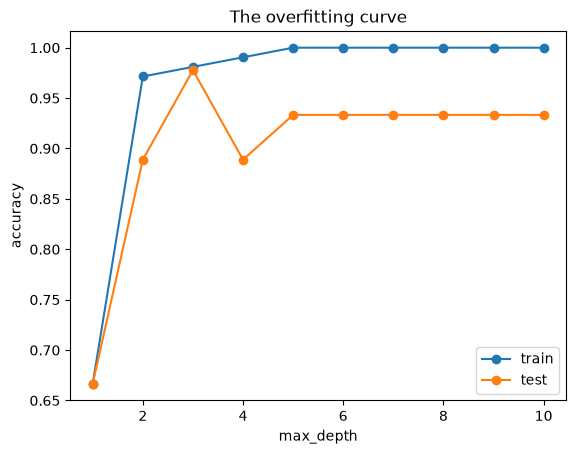

In [5]:
unlimited = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("unlimited tree:",
      "train", round(accuracy_score(y_train, unlimited.predict(X_train)), 3),
      "| test", round(accuracy_score(y_test, unlimited.predict(X_test)), 3))
# train ~ 1.0, test ~ 0.93 -> memorization

# Manual hyperparameter sweep
depths = range(1, 11)
train_scores, test_scores = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(depths, train_scores, "o-", label="train")
plt.plot(depths, test_scores, "o-", label="test")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.legend(); plt.title("The overfitting curve")
plt.show()


## Beginner example: the readable tree

---


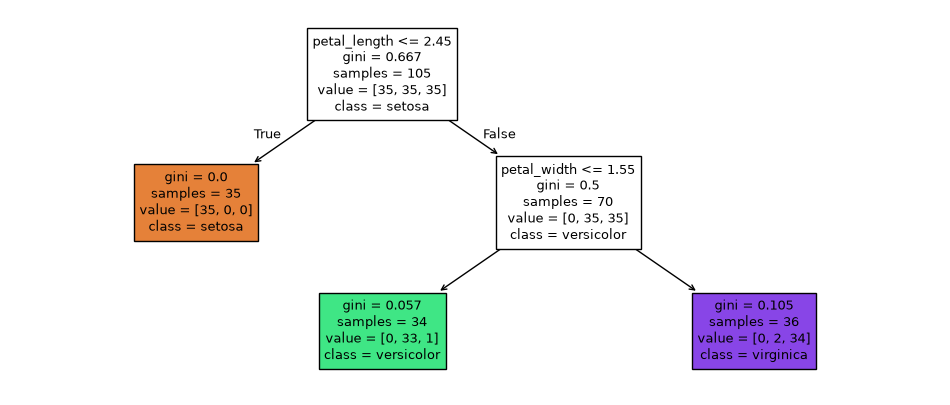

test accuracy: 0.889


In [6]:
tree_small = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(12, 5))
plot_tree(tree_small, feature_names=X.columns, class_names=y.unique(),
          filled=True, fontsize=9)
plt.show()

print("test accuracy:", round(accuracy_score(y_test, tree_small.predict(X_test)), 3))


## Intermediate example: penguins, probabilities included

---


In [7]:
penguins = sns.load_dataset("penguins").dropna()
Xp = penguins[["bill_length_mm", "flipper_length_mm"]]
yp = penguins["species"]

Xtr, Xte, ytr, yte = train_test_split(Xp, yp, test_size=0.3, random_state=42, stratify=yp)

logreg = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
pred = logreg.predict(Xte)

print(confusion_matrix(yte, pred))
print(classification_report(yte, pred))

# Probabilities: how confident is the model?
proba = logreg.predict_proba(Xte)
print("classes:", logreg.classes_)
print("first 3 predictions (probabilities):")
print(proba[:3].round(2))


[[42  2  0]
 [ 0 20  0]
 [ 0  1 35]]
              precision    recall  f1-score   support

      Adelie       1.00      0.95      0.98        44
   Chinstrap       0.87      1.00      0.93        20
      Gentoo       1.00      0.97      0.99        36

    accuracy                           0.97       100
   macro avg       0.96      0.98      0.96       100
weighted avg       0.97      0.97      0.97       100

classes: ['Adelie' 'Chinstrap' 'Gentoo']
first 3 predictions (probabilities):
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


## Exercises

---


### Exercise 1 — Confusion matrix reading

From the titanic confusion matrix printed above: how many true positives,
false positives, false negatives, and true negatives? Write them as a
tuple (TP, FP, FN, TN) in markdown. (Answer: (32, 9, 12, 55) — verify by
re-running.)

In [8]:
# your code here - reprint the matrix and count
print(confusion_matrix(yte, pred))


[[42  2  0]
 [ 0 20  0]
 [ 0  1 35]]


### Exercise 2 — Metric choice

For each scenario, pick the metric to optimize (precision or recall) and
justify in one sentence: (a) spam filter, (b) cancer screening, (c) fraud
alerts on credit cards.

In [9]:
# Write your answers in markdown:
#   (a) spam filter -> precision (don't hide real emails in spam)
#   (b) cancer screening -> recall (never miss a case)
#   (c) fraud alerts -> precision (don't block legitimate purchases)
print("answers in markdown")


answers in markdown


### Exercise 3 — k tuning

For k-NN on iris, try `k` in [1, 3, 5, 15] and report train and test
accuracy for each. What happens to the train–test gap as k grows?

In [10]:
# your code here


In [11]:
# Solution
for k in [1, 3, 5, 15]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f"k={k:2d}  train {tr:.3f}  test {te:.3f}")


k= 1  train 1.000  test 0.933
k= 3  train 0.962  test 0.956
k= 5  train 0.971  test 0.978


k=15  train 0.981  test 0.956


## Challenge exercise

Build the best small classifier you can for titanic survival:

1. Features: `pclass`, `age`, `fare` (drop missing first).
2. Try logistic regression and a tree; compare test accuracy AND the
   confusion matrices (survivors are the positive class).
3. Sweep `max_depth` 2–8 for the tree and pick the best test value.
4. State, in markdown, which model you'd choose and one limitation of using
   accuracy alone here.

In [12]:
# your code here


In [13]:
# Solution
best_acc, best_depth = 0, None
for d in range(2, 9):
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    if acc > best_acc:
        best_acc, best_depth = acc, d
print("best tree depth:", best_depth, "| accuracy:", round(best_acc, 3))
print("logistic accuracy:", round(accuracy_score(yte, LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict(Xte)), 3))


best tree depth:

 5 | accuracy: 0.96


logistic accuracy:

 0.97


## Recap

- Three classifiers, one API: k-NN (neighbors), logistic (probabilities),
  trees (readable rules).
- Confusion matrix → accuracy, precision, recall, F1 — choose by error cost.
- Accuracy lies on imbalanced data; report the matrix and beat the baseline.
- Overfitting = train ≫ test; fix with `max_depth`/`min_samples_leaf`.
- `stratify=y` keeps rare classes present in both splits.
- `predict_proba` gives calibrated confidence, not just labels.

---


## Questions

1. How does k-NN decide a new point's class?
2. What does `predict_proba` return that `predict` doesn't?
3. Define precision and recall in words.
4. In cancer screening, which metric matters most and why?
5. Why does k=1 (or unlimited depth) overfit?
6. What does `stratify=y` do?

---
**Next:** notebook 13 — Clustering.
